# SITCOM for Super-Resolution and Inpainting

This notebook is converted from `Demo_for_sr_inpainting.py` and organized for interactive use.

Workflow:
1. Load configs and runtime settings
2. Preview one image under SR and Inpainting measurements
3. Run SITCOM for both tasks with progress bars
4. Compare `Original | Measurement | SITCOM Recon` for both tasks

In [113]:
# Cell1
from pathlib import Path
import os
import sys
import yaml

def locate_sitcom_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'configs').exists() and (p / 'SITCOM.py').exists():
            return p
        if (p / 'SITCOM' / 'configs').exists() and (p / 'SITCOM' / 'SITCOM.py').exists():
            return p / 'SITCOM'
    raise FileNotFoundError('Could not locate SITCOM root from current working directory.')

repo = locate_sitcom_root(Path.cwd())
os.chdir(repo)


In [114]:
# Cell2
tasks = ['super_resolution', 'inpainting']
# tasks = ['inpainting']
gpu_id = 3
use_cuda = True
run_now = True
force_rerun = True
random_seed = 42

task_params = {
    'super_resolution': {
        'num_steps':     30,
        'n_step':        20,
        'learning_rate': 0.02,
        'noiselevel':    0.05,  
    },
    'inpainting': {
        'num_steps':     40,
        'n_step':        20,
        'learning_rate': 0.01,
        'noiselevel':    0.05,  
    },
}

config_paths = {
    'super_resolution': repo / 'configs' / 'super_resolution_config.yaml',
    'inpainting':       repo / 'configs' / 'inpainting_config.yaml',
    'model':            repo / 'configs' / 'model_config.yaml',
    'diffusion':        repo / 'configs' / 'diffusion_config.yaml',
}

configs = {}
for name, path in config_paths.items():
    with open(path, 'r') as f:
        configs[name] = yaml.load(f, Loader=yaml.FullLoader)

for t in tasks:
    p = task_params[t]
    print(f"{t} params: num_steps={p['num_steps']}, n_step={p['n_step']}, "
          f"lr={p['learning_rate']}, noise={p['noiselevel']}")
# print('model_path =', configs['model']['model_path'])

super_resolution params: num_steps=30, n_step=20, lr=0.02, noise=0.05
inpainting params: num_steps=40, n_step=20, lr=0.01, noise=0.05


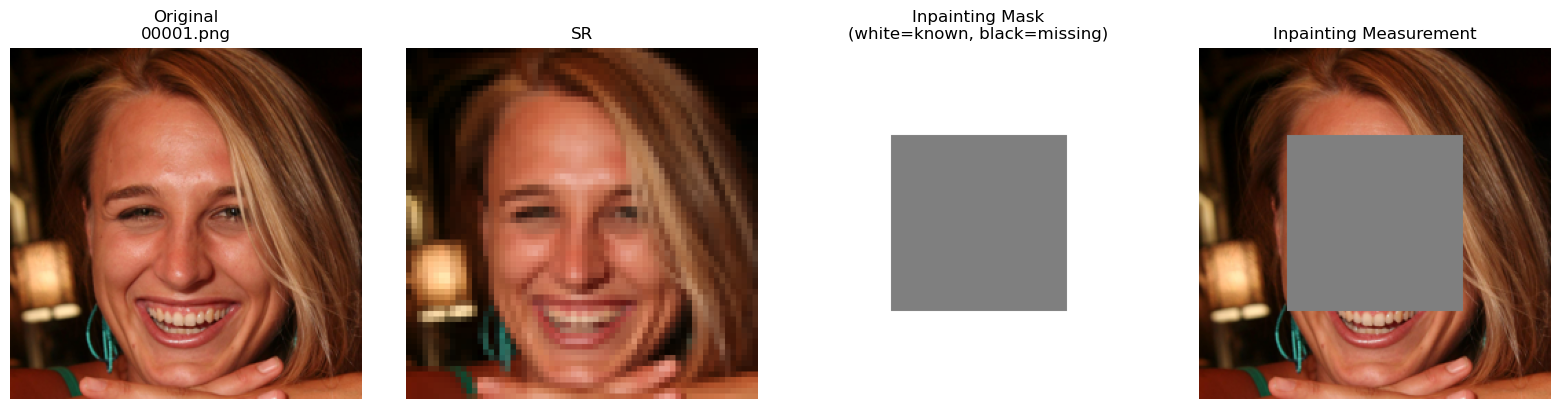

Mask ratio (missing): 0.250


In [ ]:
# Cell3
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from guided_diffusion.measurements import get_operator

def to_tensor_256_rgb(img_path):
    img = Image.open(img_path).convert('RGB').resize((256, 256))
    arr = np.array(img).astype(np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
    return t * 2 - 1

def t2img(t):
    t = t.detach().cpu().clamp(-1, 1)
    t = (t + 1) / 2
    return np.clip(t.squeeze(0).permute(1, 2, 0).numpy(), 0, 1)

sr_root   = Path(configs['super_resolution']['data']['root'])
inp_root  = Path(configs['inpainting']['data']['root'])
sr_images = sorted(sr_root.glob('**/*.png'))
if not sr_images:
    raise FileNotFoundError(f'No PNG files in: {sr_root}')

src_path = sr_images[1]
x = to_tensor_256_rgb(src_path)

# SR 
sr_op   = get_operator(device='cpu', **configs['super_resolution']['measurement']['operator'])
sr_y    = sr_op.forward(x)
sr_meas = sr_op.transpose(sr_y).clamp(-1, 1)

inp_op = get_operator(device='cpu', **configs['inpainting']['measurement']['operator'])

inp_mask_cfg = configs['inpainting']['measurement'].get('mask_opt', {})

if inp_mask_cfg.get('mask_type', 'box') == 'random':
    torch.manual_seed(random_seed)
    mask_ratio = inp_mask_cfg.get('mask_prob_range', [0.5, 0.5])[0]
    mask = (torch.rand(1, 1, 256, 256) > mask_ratio).float().expand(1, 3, 256, 256)
else:
    mask = torch.ones(1, 3, 256, 256)
    mask[:, :, 64:192, 64:192] = 0    # 128×128

inp_meas = inp_op.forward(x, mask=mask)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(t2img(x));                   axs[0].set_title(f'Original\n{src_path.name}')
axs[1].imshow(t2img(sr_meas));             axs[1].set_title('SR Measurement')
axs[2].imshow(t2img(mask[0].unsqueeze(0))); axs[2].set_title('Inpainting Mask\n(white=known, black=missing)')  # ✅
axs[3].imshow(t2img(inp_meas));            axs[3].set_title('Inpainting Measurement')
for ax in axs: ax.axis('off')
plt.tight_layout()
plt.savefig(str(repo / 'results' / 'preview_measurements.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'Mask ratio (missing): {(1 - mask.mean()).item():.3f}')

In [117]:
# Cell4
# quick_test = True # quick test
quick_test = False         
quick_test_task = 'inpainting'
import subprocess
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

task_cfg_map = {
    'super_resolution': 'configs/super_resolution_config.yaml',
    'inpainting':       'configs/inpainting_config.yaml',
}

def count_input_images(task_name):
    root = Path(configs[task_name]['data']['root'])
    return len(sorted(root.glob('**/*.png')))

def run_sitcom_task(task_name):
    save_dir = repo / 'results' / f'demo_{task_name}'
    save_dir.mkdir(parents=True, exist_ok=True)

    total_imgs = count_input_images(task_name)
    existing   = sorted(save_dir.glob('result_image_*.png'))
    if (not force_rerun) and len(existing) >= total_imgs > 0:
        print(f'[{task_name}] skip: found {len(existing)}/{total_imgs} outputs')
        return {'task': task_name, 'save_dir': save_dir, 'exit_code': 0}

    # quick test
    if quick_test and task_name == quick_test_task:
        import shutil
        test_dir = repo / 'results' / '_quick_test_data'
        test_dir.mkdir(parents=True, exist_ok=True)
        orig_imgs = sorted(Path(configs[task_name]['data']['root']).glob('**/*.png'))
        shutil.copy(orig_imgs[0], test_dir / orig_imgs[0].name)
        data_root_override = str(test_dir)
    else:
        data_root_override = None

    p = task_params[task_name]

    device = f'cuda:{gpu_id}' if use_cuda else 'cpu'
    cmd = [
        sys.executable, '-u', 'SITCOM_with_noise.py',
        '--model_config=configs/model_config.yaml',
        '--diffusion_config=configs/diffusion_config.yaml',
        f'--task_config={task_cfg_map[task_name]}',
        f'--gpu={gpu_id}',
        f'--device={device}',
        f'--learning_rate={p["learning_rate"]}',   
        f'--num_steps={p["num_steps"]}',            
        f'--n_step={p["n_step"]}',                  
        f'--noiselevel={p["noiselevel"]}',          
        f'--random_seed={random_seed}',
        f'--save_path={save_dir}',
        *([ f'--file_path={data_root_override}'] if data_root_override else []),  # ← 加这行
    ]

    print(f'\n===== [{task_name}] =====')
    # print(' '.join(str(c) for c in cmd))

    proc = subprocess.Popen(
        cmd, cwd=str(repo),
        stdout=subprocess.PIPE, stderr=subprocess.PIPE,
        text=True, bufsize=1,
    )
    pbar = tqdm(total=total_imgs, desc=task_name, unit='img') if (tqdm and total_imgs > 0) else None
    stdout_tail = []
    for line in proc.stdout:
        line = line.rstrip('\n')
        if line:
            stdout_tail = (stdout_tail + [line])[-20:]
        if 'After diffusion PSNR' in line and pbar:
            pbar.update(1)

    return_code = proc.wait()
    stderr_text = proc.stderr.read().strip()
    if pbar: pbar.close()

run_records = []
if run_now:
    for t in tasks:
        run_records.append(run_sitcom_task(t))
else:
    print('run_now=False -> skip')


===== [super_resolution] =====


super_resolution:   0%|          | 0/10 [00:00<?, ?img/s]


===== [inpainting] =====


inpainting:   0%|          | 0/10 [00:00<?, ?img/s]

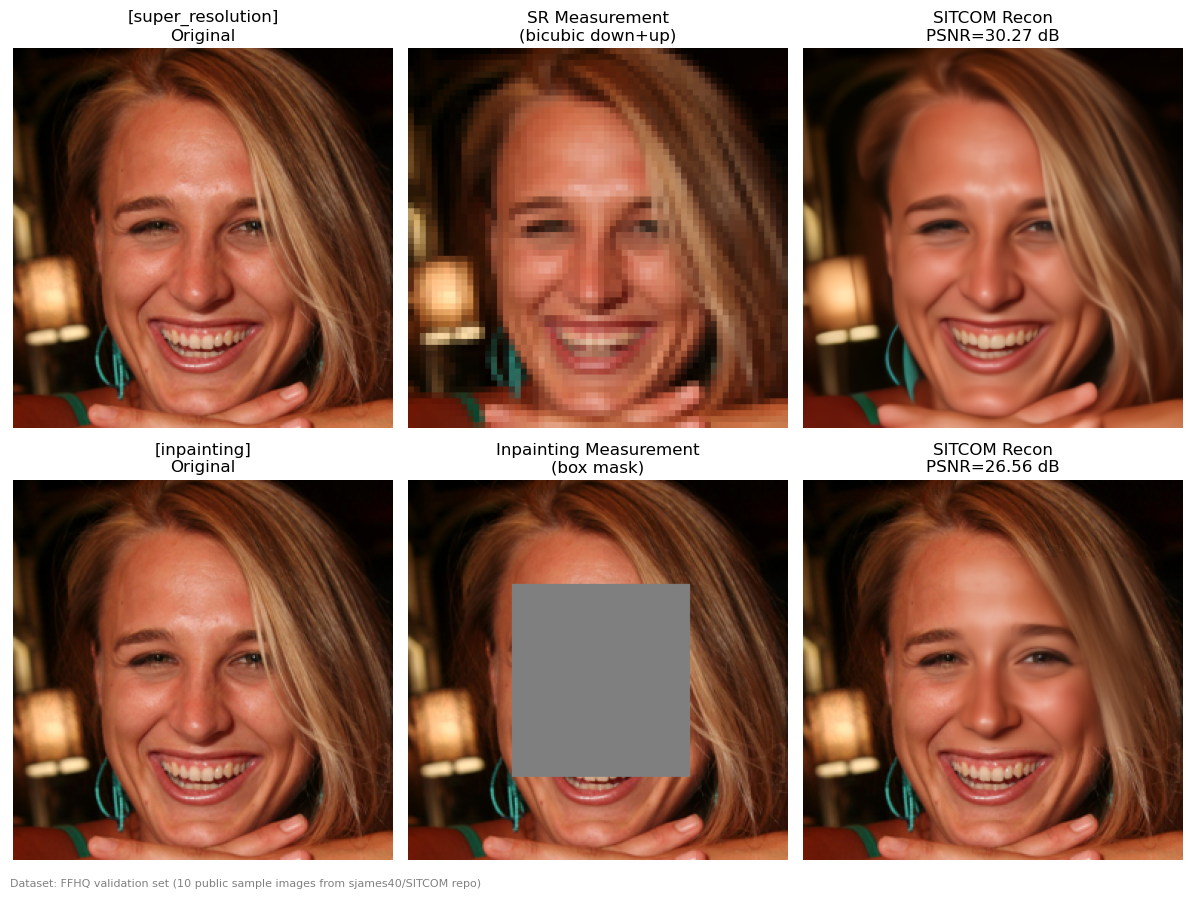

Saved comparison to: /egr/research-slim/hy2786/SITCOM/results/comparison_all_tasks.png


In [ ]:
# Cell5
compare_tasks   = ['super_resolution', 'inpainting']
index_to_show   = 1

fig, axs = plt.subplots(len(compare_tasks), 3, figsize=(12, 4.5 * len(compare_tasks)))
if len(compare_tasks) == 1:
    axs = [axs]

for r, tname in enumerate(compare_tasks):
    data_root = Path(configs[tname]['data']['root'])
    srcs = sorted(data_root.glob('**/*.png'))

    if not srcs:
        for c in range(4):
            axs[r][c].text(0.5, 0.5, f'No PNG in\n{data_root}', ha='center', va='center')
            axs[r][c].axis('off')
        continue

    idx = min(index_to_show, len(srcs) - 1)
    x   = to_tensor_256_rgb(srcs[idx])
    op  = get_operator(device='cpu', **configs[tname]['measurement']['operator'])

    if tname == 'super_resolution':
        y    = op.forward(x)
        meas = op.transpose(y).clamp(-1, 1)
        meas_title = 'SR Measurement'
    else:
        # ✅ use same mask as Cell 3
        mask_local = torch.ones(1, 3, 256, 256)
        mask_local[:, :, 70:200, 70:190] = 0
        meas = op.forward(x, mask=mask_local)
        meas_title = 'Inpainting Measurement'

    out_dir    = repo / 'results' / f'demo_{tname}'
    recon_path = out_dir / f'result_image_{idx}.png'

    # compute PSNR
    def compute_psnr(gt, pred):
        gt_np   = t2img(gt)
        pred_np = np.array(pred.convert('RGB').resize((256, 256))).astype(np.float32) / 255.
        mse     = np.mean((gt_np - pred_np) ** 2)
        return float('inf') if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

    axs[r][0].imshow(t2img(x)); axs[r][0].set_title(f'[{tname}]\nOriginal')
    axs[r][1].imshow(t2img(meas)); axs[r][1].set_title(meas_title)

    if recon_path.exists():
        recon_pil  = Image.open(recon_path).convert('RGB')
        psnr_val   = compute_psnr(x, recon_pil)
        axs[r][2].imshow(recon_pil)
        axs[r][2].set_title(f'SITCOM Recon\nPSNR={psnr_val:.2f} dB')
    else:
        axs[r][2].text(0.5, 0.5, f'Missing\n{recon_path.name}', ha='center', va='center')
        axs[r][2].set_title('SITCOM Recon (missing)')
        axs[r][3].axis('off')

    for c in range(3): axs[r][c].axis('off')

# Dataset: FFHQ validation set (10 public sample images from sjames40/SITCOM repo)
fig.text(0.01, 0.01,
    'Dataset: FFHQ validation set (10 public sample images from sjames40/SITCOM repo)',
    fontsize=8, color='gray')
plt.tight_layout()
save_path = repo / 'results' / 'comparison_all_tasks.png'
plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved comparison to: {save_path}')